## AI Programming Foundations Project

## Name: Sayed Saidoo

## Dataset: Wine(Chemical properties and quality scores)

## Project Overview

This project demonstrates a reproducible data analysis workflow using the Wine Quality datasets for Portuguese "Vinho Verde" red and white wines. The workflow includes data ingestion, cleaning, exploratory analysis, visualization, and interpretation using Python, Pandas, Numpy, Matplotlib, and Seaborn.

The objective is to explore how physicochemical properties relate to expert-rated wine quality and to compare patterns between red and white wines.

### Core Dependencies and Data Ingestion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment Ready")

Environment Ready


In [2]:
df_red = pd.read_csv("../data/winequality-red.csv", sep=";")
df_red.sample(7)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
113,10.1,0.31,0.44,2.3,0.080,22.0,46.0,0.99880,3.32,0.67,9.7,6
876,7.1,0.47,0.00,2.2,0.067,7.0,14.0,0.99517,3.40,0.58,10.9,4
669,11.3,0.34,0.45,2.0,0.082,6.0,15.0,0.99880,2.94,0.66,9.2,6
1125,8.8,0.24,0.35,1.7,0.055,13.0,27.0,0.99394,3.14,0.59,11.3,7
520,9.8,0.25,0.49,2.7,0.088,15.0,33.0,0.99820,3.42,0.90,10.0,6
751,8.3,0.65,0.10,2.9,0.089,17.0,40.0,0.99803,3.29,0.55,9.5,5
1426,7.7,0.23,0.37,1.8,0.046,23.0,60.0,0.99710,3.41,0.71,12.1,6


In [3]:
df_white = pd.read_csv("../data/winequality-white.csv", sep=";")
df_white.sample(7)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4375,6.0,0.320,0.32,4.8,0.041,40.0,186.0,0.99235,3.22,0.54,11.0,6
4810,5.4,0.375,0.40,3.3,0.054,29.0,147.0,0.99482,3.42,0.52,9.1,5
848,8.7,0.230,0.32,13.4,0.044,35.0,169.0,0.99975,3.12,0.47,8.8,7
3258,7.4,0.190,0.31,14.5,0.045,39.0,193.0,0.99860,3.10,0.50,9.2,6
384,6.0,0.360,0.39,3.2,0.027,20.0,125.0,0.99100,3.38,0.39,11.3,7
588,6.9,0.280,0.27,2.1,0.036,42.0,121.0,0.99260,3.42,0.49,10.8,7
2950,6.0,0.280,0.25,1.8,0.042,8.0,108.0,0.99290,3.08,0.55,9.0,5


### Data Inspection and Cleaning

In [4]:
print(df_red.shape)
print(df_white.shape)

(1599, 12)
(4898, 12)


In [5]:
df_red.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df_white.info()

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


- Initial inspection of both datasets showed that all columns were assigned appropriate numeric data types and no missing values were detected. This suggests the datasets are relatively clean and suitable for analysis, though additional validation checks such as duplicate detection and consistency checks will still be performed.

In [7]:
# Check for duplicate rows
print(f"Red wine duplicates: {df_red.duplicated().sum()}")
print(f"White wine duplicates: {df_white.duplicated().sum()}")

# Verify column names match
print(df_red.columns.equals(df_white.columns))

# Verify data types match
print(df_red.dtypes.equals(df_white.dtypes))

Red wine duplicates: 240
White wine duplicates: 937
True
True


In [8]:
duplicates_red = df_red[df_red.duplicated()]
duplicates_white = df_white[df_white.duplicated()]

In [9]:
duplicates_red.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1074,7.5,0.770,0.20,8.1,0.098,30.0,92.0,0.99892,3.20,0.58,9.2,5
984,12.2,0.450,0.49,1.4,0.075,3.0,6.0,0.99690,3.13,0.63,10.4,5
1557,6.6,0.855,0.02,2.4,0.062,15.0,23.0,0.99627,3.54,0.60,11.0,6
971,10.4,0.260,0.48,1.9,0.066,6.0,10.0,0.99724,3.33,0.87,10.9,6
902,7.4,0.635,0.10,2.4,0.080,16.0,33.0,0.99736,3.58,0.69,10.8,7


In [10]:
duplicates_white.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
460,7.1,0.21,0.27,8.6,0.056,26.0,111.0,0.99560,2.95,0.52,9.5,5
1434,7.4,0.25,0.49,1.1,0.042,35.0,156.0,0.99170,3.13,0.55,11.3,5
1054,7.0,0.31,0.52,1.7,0.029,5.0,61.0,0.99180,3.07,0.43,10.4,5
4632,6.3,0.30,0.91,8.2,0.034,50.0,199.0,0.99394,3.39,0.49,11.7,6
3839,6.2,0.31,0.23,3.3,0.052,34.0,113.0,0.99429,3.16,0.48,8.4,5


- Duplicate rows were identified during the initial inspection and will be removed to improve data quality and prevent repeated observations from influencing the analysis.

- A consistency check was performed prior to merging the datasets. Both datasets contain the same columns and data types, indicating they can be combined safely without requiring structural modifications.

- The consistency check suggests that the red and white wine datasets can be merged into a single dataset for analysis. Adding a wine type indicator will allow comparisons between wine classes while preserving information about the original source of each observation.

### Cleaning

In [11]:
def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove duplicate rows from a dataframe.
    
    Parameters:
    df (pd.DataFrame): Input dataframe.
    
    Returns:
    pd.DataFrame: Dataframe with duplicate rows removed.
    
    """
    return df.drop_duplicates()

In [12]:
df_red = remove_duplicates(df_red)
df_white = remove_duplicates(df_white)

In [13]:
print(df_red.shape)
print(df_white.shape)

(1359, 12)
(3961, 12)


In [14]:
def add_wine_type(df: pd.DataFrame, wine_type: str) -> pd.DataFrame:
    """
    Add a wine type identifier to a dataframe.
     
    Parameters:
    
        df (pd.DataFrame): Input dataframe.
        wine_type (str): Label indicating the wine type.
    
    Returns:
        pd.DataFrame: Dataframe with a new wine_type column.
    
    """
    df = df.copy()
    df["wine_type"] = wine_type
    return df

In [15]:
df_red = add_wine_type(df_red, "Red")
df_white = add_wine_type(df_white, "White")

In [16]:
df_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Red
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,Red


In [17]:
df_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,White
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,White
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,White
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,White
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6,White


- A wine_type column was added prior to merging the datasets so that observations from red and white wines could be distinguished after consolidation.
This preserves the origin of each record and enables comparative analysis between wine classes.

In [18]:
def merge_wine_datasets(df_red: pd.DataFrame, df_white: pd.DataFrame) -> pd.DataFrame:
    """
    Merge the red and white wine datasets into a single dataframe.
    
    Parameters:
        df_red (pd.DataFrame): Cleaned red wine dataframe.
        df_white (pd.DataFrame): Cleaned white wine dataframe.
     
    Returns:
        pd.DataFrame: Combined wine dataframe.
    """
    return pd.concat([df_red, df_white], ignore_index=True)

In [19]:
df_wine = merge_wine_datasets(df_red, df_white)

In [20]:
# Confirmation of merge success
df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Red
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,Red


In [21]:
# Sanity check for white wine rows
df_wine.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
5315,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,White
5316,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,White
5317,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,White
5318,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,White
5319,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,White


### Exploratory Data Analysis

In [24]:
# Summary Statistics
def summary_statistics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generate summary statistics for the wine dataset.
    
    Parameters:
    
    df (pd.DataFrame): Input dataframe.
     
    Returns:
    
    pd.DataFrame: Summary statistics for numerical features.
    """
    return df.describe()
summary_statistics(df_wine)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241,5.795677
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933,0.879772
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000,6.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


**Interpretation**

 - The combined dataset contains 5,320 wine observations with no missing values.

 - Several variables exhibit substantial variability, particularly residual sugar, free sulfur dioxide, and total sulfur dioxide, as indicated by their relatively large standard deviations and wide ranges. This suggests meaningful differences between wine samples and potential opportunities for further investigation.

- Wine quality scores range from 3 to 9, with a median and 75th quartile settling at 6, indicating that most wines are concentrated around average quality ratings. This suggests the dataset contains fewer low and high-quality wines, which may introduce class imbalance considerations in future predictive modeling tasks if project is extended into predicitve modeling.

- The difference between the mean (5.80) and median (6.00) quality score is small, suggesting the quality distribution is not heavily skewed.

- The presence of large differences between minimum and maximum values for several variables suggests potential outliers or naturally occurring variability within the wine production process. These observations may warrant further examination through visualization and correlation analysis.

In [27]:
# Looking at average feature values by wine type
def wine_type_means(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generate average feature values grouped by wine type.
    
    Parameters:
    df (pd.DataFrame): Combined wine dataset.
     
    Returns:
    pd.DataFrame: Mean values of numerical features grouped by wine type.
    """
    return df.groupby("wine_type").mean(numeric_only=True)
wine_type_means(df_wine)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
wine_type,,,,,,,,,,,,
Red,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
White,6.839346,0.280538,0.334332,5.914819,0.045905,34.889169,137.193512,0.993790,3.195458,0.490351,10.589358,5.854835


**Interpretation**

- Both wine types received similar average quality ratings. Red wines achieved an average quality score of 5.62, while white wines achieved an average quality score of 5.85, suggesting that expert ratings are broadly comparable across both wine categories.

- White wines contain substantially higher average levels of residual sugar, free and total sulfur dioxide than red wines. These differences may reflect distinct production and preservation processes between the two wine types or just a difference in the chemical composition of raw products themselves.

- Red wines exhibit higher average values for fixed acidity, volatile acidity, and sulphates, indicating notable differences in their physicochemical composition compared to white wines.

- Despite these chemical differences, the similarity in average quality scores suggests that wine quality is likely influenced by multiple interacting factors rather than a single physicochemical characteristic.

- As a next step it would be interesting to see if there are any correlations/interactions between features (dependent/independent)

In [30]:
df_wine.corr(numeric_only=True)["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.469422
citric acid             0.097954
free sulfur dioxide     0.054002
sulphates               0.041884
pH                      0.039733
total sulfur dioxide   -0.050296
residual sugar         -0.056830
fixed acidity          -0.080092
chlorides              -0.202137
volatile acidity       -0.265205
density                -0.326434
Name: quality, dtype: float64

**Interpretation**

- Alcohol exhibited the strongest positive relationship with quality (0.47), suggesting that wines with higher alcohol content tended to receive higher expert quality ratings.

- Density showed the strongest negative relationship with quality (-0.33), while volatile acidity (-0.27) and chlorides (-0.20) also demonstrated moderate negative relationships. These characteristics may be associated with lower-rated wines.

- Most remaining variables exhibited relatively weak correlations with quality, perhaps reinforcing early indications that wine quality is likely influenced by a combination of factors rather than a single physicochemical measurement.

- While correlation does not imply causation, these results suggest that alcohol, density, volatile acidity, and chlorides may be the most informative variables for understanding wine quality within this dataset.

### Visualizations

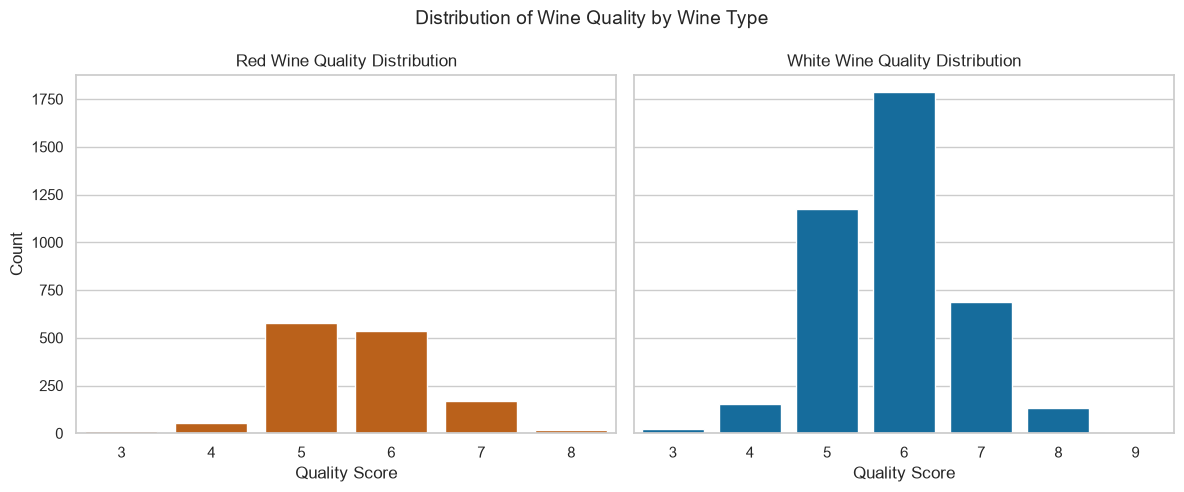

In [38]:
# We will look at the Distribution or Wine Quality by Wine Type, given the sample imbalance we will create a subplot for each wine type.
sns.set_theme(style="whitegrid")
RED = "#D55E00" # colors that take color blindness into account
BLUE = "#0072B2"

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Red Wine
sns.countplot(data=df_wine[df_wine["wine_type"] == "Red"], x="quality", color=RED, ax=axes[0])
axes[0].set_title("Red Wine Quality Distribution")
axes[0].set_xlabel("Quality Score")
axes[0].set_ylabel("Count")

# White Wine
sns.countplot(data=df_wine[df_wine["wine_type"] == "White"], x="quality", color=BLUE, ax=axes[1])
axes[1].set_title("White Wine Quality Distribution")
axes[1].set_xlabel("Quality Score")
axes[1].set_ylabel("Count")

plt.suptitle("Distribution of Wine Quality by Wine Type", fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation**

- Both red and white wines are concentrated around quality scores of 5 and 6, indicating that most wines in the dataset received average expert ratings, reinforcing our previous EDA. White wines exhibit a slightly higher concentration of quality scores above 6, which is consistent with the grouped analysis showing a marginally higher average quality rating for white wines. High-quality and low-quality wines are relatively uncommon in both groups, suggesting that extreme ratings are underrepresented within the dataset.

Text(0, 0.5, 'Alcohol (%)')

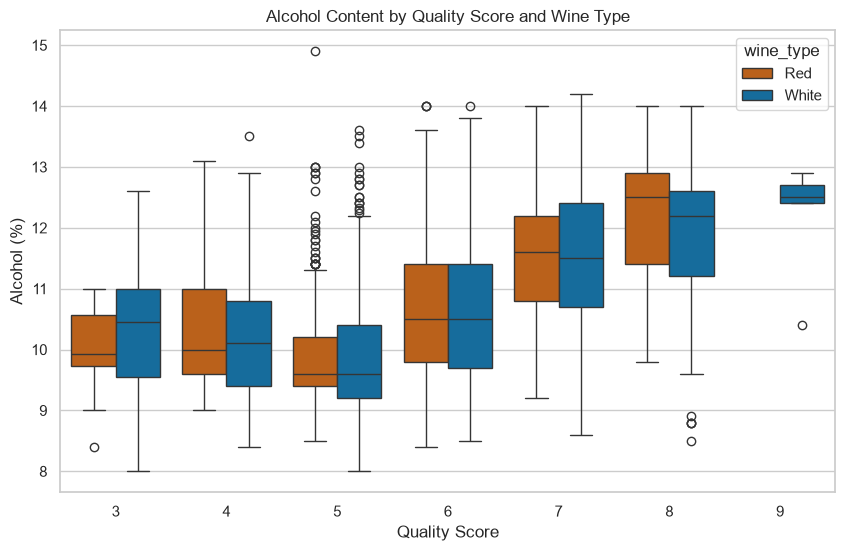

In [39]:
palette = {
"Red": "#D55E00",
"White": "#0072B2"
}
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_wine, x="quality", y="alcohol", hue="wine_type", palette=palette)
plt.title("Alcohol Content by Quality Score and Wine Type")
plt.xlabel("Quality Score")
plt.ylabel("Alcohol (%)")

**Interpretation**

- A clear positive relationship is observed between alcohol content and wine quality. Median alcohol levels generally increase as quality scores rise, particularly for wines rated 6 and above. This finding is consistent with the correlation analysis, which identified alcohol as the strongest positive correlate of quality.

- While the overall trend is upward, several outliers are present. Notably, some wines with a quality score of 5 exhibit relatively high alcohol content, suggesting that alcohol alone is insufficient to explain expert quality ratings. This reinforces the earlier observation that wine quality is likely influenced by multiple interacting physicochemical characteristics rather than a single dominant factor.

- An additional observation is that no red wines received the highest quality score of 9 in the dataset, while a small number of white wines achieved this rating. Although the sample of highly rated wines is small, this may partially explain the slightly higher average quality observed among white wines.

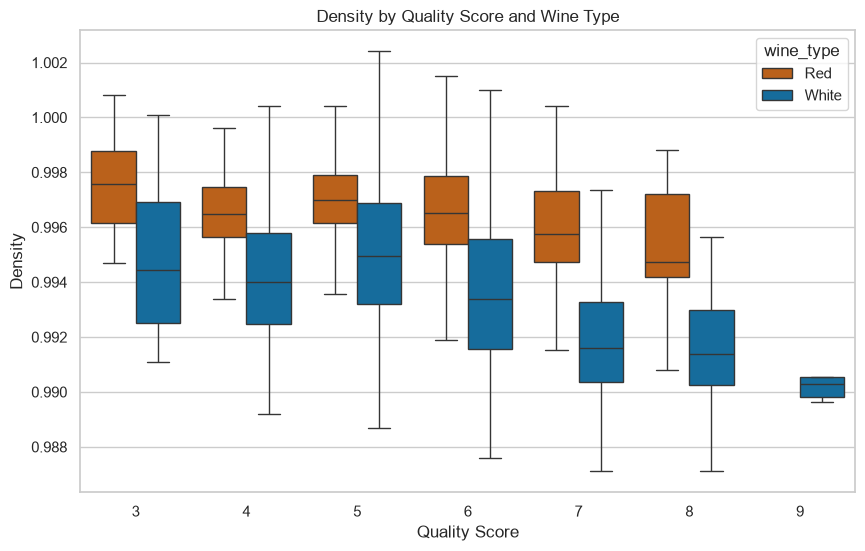

In [42]:
# Density by Quality score by wine type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_wine, x="quality", y="density", hue="wine_type",showfliers=False, palette=palette)
plt.title("Density by Quality Score and Wine Type")
plt.xlabel("Quality Score")
plt.ylabel("Density")
plt.show()

**Notebook Note**

An extreme density observation was retained in the dataset but omitted from the visual display using showfliers=False. This approach improves readability by allowing the central distribution of density values to be examined more clearly while preserving the original data for analysis.

**Interpretation**

- The density distributions differ between red and white wines, reflecting the compositional differences identified during exploratory analysis. Despite these differences, a consistent trend is observed across both wine types: higher-quality wines tend to exhibit lower density values, focusing on the median values here.

- The relationship becomes particularly noticeable for wines with quality scores above 6, where median density values generally decrease slightly as quality ratings increase. This finding is consistent with the correlation analysis, which identified density as the strongest negative correlate of wine quality in the combined dataset.

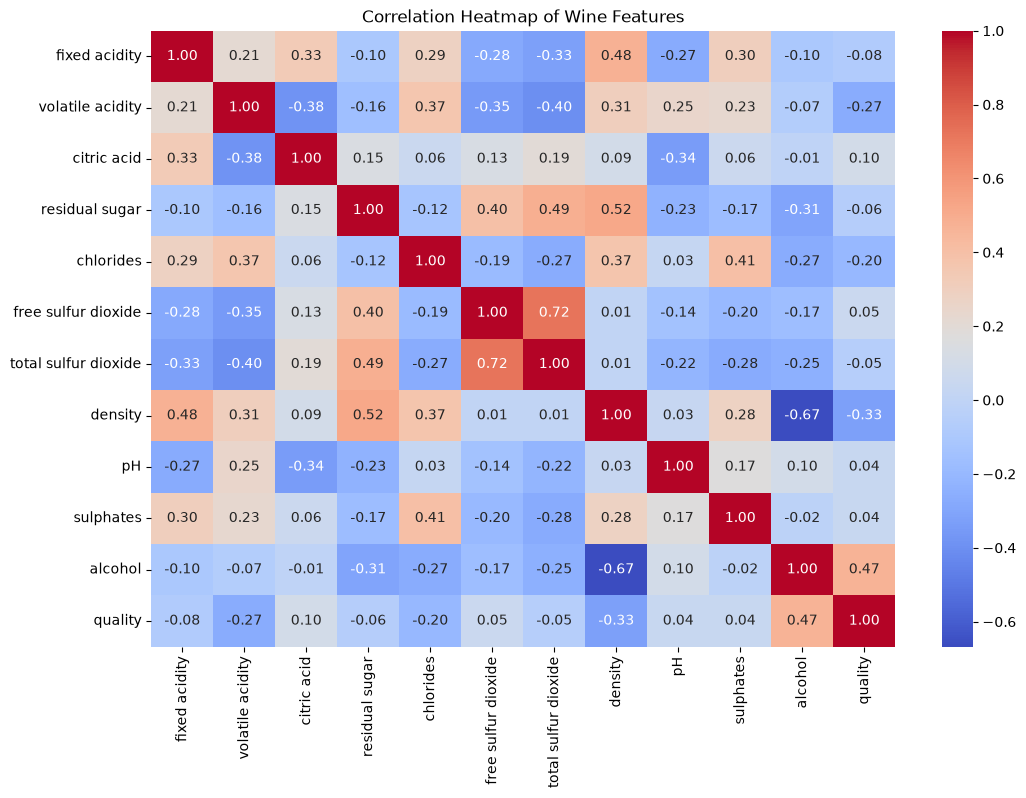

In [34]:
# correlation plot for features
plt.figure(figsize=(12, 8))
sns.heatmap(df_wine.corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Wine Features")
plt.show()

**Interpretation**

- The correlation heatmap provides an overall view of relationships between the physicochemical properties and wine quality ratings. Consistent with the earlier correlation analysis, alcohol content exhibits the strongest positive relationship with quality, while density shows the strongest negative relationship.

- Several relationships between predictor variables are also apparent. Free sulfur dioxide and total sulfur dioxide demonstrate a strong positive correlation (0.72) which aligns, while alcohol and density exhibit a strong negative correlation (-0.67). Moderate positive relationships are observed between residual sugar and density, as well as residual sugar and total sulfur dioxide.

- Despite these associations, most correlation coefficients remain below 0.60 in absolute value, indicating limited multicollinearity among the measured variables. This suggests that wine quality is influenced by multiple physicochemical properties acting together rather than a small number of highly correlated features.

## Summary and Overall Interpretations



**What I Learned from the Dataset**

This analysis explored the physicochemical properties and expert quality ratings of Portuguese "Vinho Verde" red and white wines. After removing duplicate records and merging the datasets, the final dataset contained 5,320 observations with no missing values, the dataset presented clean data with appropriate data types and high data quality from the sensor readings(numerical). The analysis showed that red and white wines differ noticeably in their chemical composition, particularly in measures such as residual sugar, sulfur dioxide, acidity, and density. Several physicochemical features exhibited measurable relationships with wine quality but overall, quality was suggested to be influenced by multiple physicochemical properties acting together rather than a small number of highly correlated features.

**Interesting Patterns and Insights**

Alcohol content exhibited the strongest positive relationship with wine quality, while density showed the strongest negative relationship. Visualizations further demonstrated that higher-quality wines generally contained higher alcohol levels and lower density values, particularly among wines with quality scores above 6. The analysis also showed that white wines contained a small number of wines rated 9, while no red wines received the highest quality rating in the dataset.

The correlation analysis revealed relatively few strong relationships among the measured variables. While some features, such as free and total sulfur dioxide, displayed moderate to strong correlations, most variables exhibited only weak to moderate associations with one another and with wine quality.

**Limitations and Assumptions**

Several limitations should be considered when interpreting these results. The dataset contains only physicochemical measurements and expert quality ratings, with no information about grape variety, production methods, wine brand, price, region, or consumer preferences. As a result, potentially important factors influencing wine quality were not available for analysis.

In addition, quality scores were not evenly distributed across all rating categories. Most wines received average ratings of 5 or 6, while very high-quality and very low-quality wines were relatively uncommon. This distribution may limit the ability to draw strong conclusions about wines at the extremes of the quality scale.

Finally, the analysis focused on identifying patterns and associations rather than establishing causal relationships. Correlation results should therefore be interpreted as indicators of association rather than evidence of cause and effect.

**Surprising or Unclear Findings**

One of the most surprising findings was that red and white wines achieved similar average quality ratings despite exhibiting substantial differences in several chemical properties. It was also notable that alcohol content showed a stronger relationship with quality than many other measured characteristics.

At the same time, no single variable demonstrated an overwhelming relationship with quality. This suggests that expert wine ratings likely reflect a combination of interacting physicochemical factors rather than a single dominant attribute. Further analysis or predictive modeling would be required to better understand how these characteristics collectively influence wine quality.

**Bias and Data Quality Considerations**

The dataset uses expert assigned quality ratings as the target variable. While expert evaluation provides a structured assessment of wine quality, these ratings may still reflect subjective preferences and may not fully represent broader consumer perceptions of wine quality. In addition, the dataset contains substantially more average-quality wines than very high- or very low-quality wines, which may influence the conclusions drawn from the analysis and could introduce bias if the dataset were later used for predictive modeling.